Shape: (50000, 26)


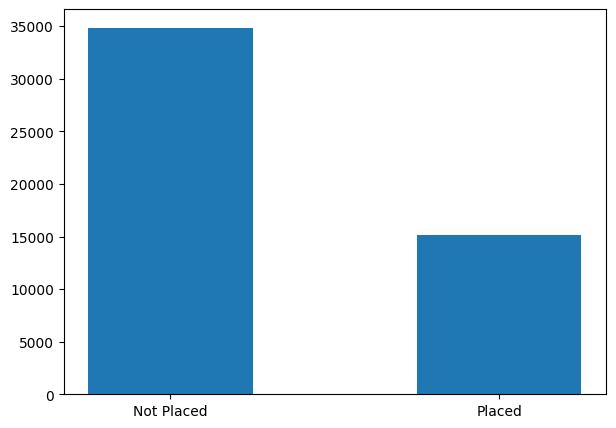

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("HR_Cleaned_For_EDA.csv")
print("Shape:", df.shape)   # should show (50000, 43)

fig, ax = plt.subplots(figsize=(7,5))

counts = df['status'].value_counts()

bars = ax.bar(
    counts.index,
    counts.values,
    width=0.5
)

plt.show()

In [3]:
df.head()


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,No,0.0,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,Willing,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [4]:
# ============================================================
# STEP 4 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Import visualization libraries
import matplotlib.pyplot as plt     # base plotting library
import seaborn as sns               # beautiful statistical charts
import pandas as pd
import numpy as np

# Set a clean, professional style for ALL charts
# 'whitegrid' adds light grid lines — easier to read values
sns.set_theme(style="whitegrid", palette="muted")

# Define colors we'll reuse across charts
PLACED_COLOR     = "#2ecc71"    # green  = Placed
NOT_PLACED_COLOR = "#e74c3c"    # red    = Not Placed
PALETTE          = [NOT_PLACED_COLOR, PLACED_COLOR]

# (Assume df is already cleaned from Step 3)

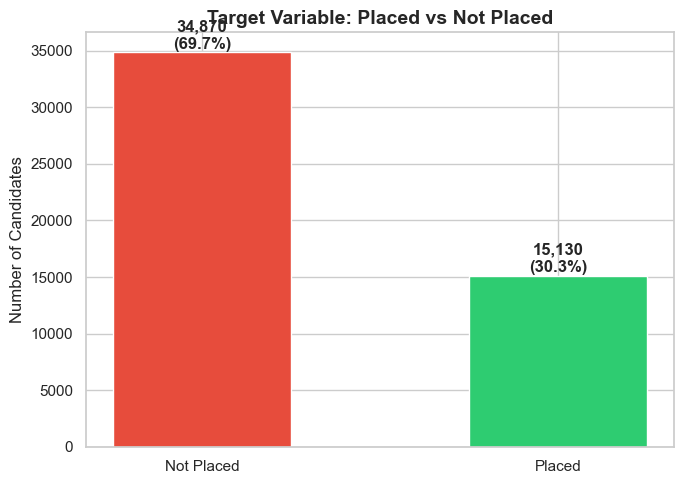

In [5]:
# ── CHART 1: How many Placed vs Not Placed? ────────────────


fig, ax = plt.subplots(figsize=(7, 5))    # create a figure & axes (canvas)

# Count how many of each status
counts = df['status'].value_counts()      # {'Not Placed': 34870, 'Placed': 15130}

# Draw the bar chart
bars = ax.bar(
    counts.index,                         # x-axis: 'Not Placed', 'Placed'
    counts.values,                        # y-axis: the counts
    color=[NOT_PLACED_COLOR, PLACED_COLOR],  # red for No, green for Yes
    edgecolor='white',                    # white border between bars
    width=0.5                             # bar width (0=thin, 1=full)
)

# Add count + % labels ON TOP of each bar
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,  # x position = center of bar
        bar.get_height() + 300,           # y position = just above bar
        f'{val:,}\n({val/len(df)*100:.1f}%)',  # text: count + percentage
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('Target Variable: Placed vs Not Placed',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Candidates')
plt.tight_layout()                        # auto-adjust spacing
plt.show()

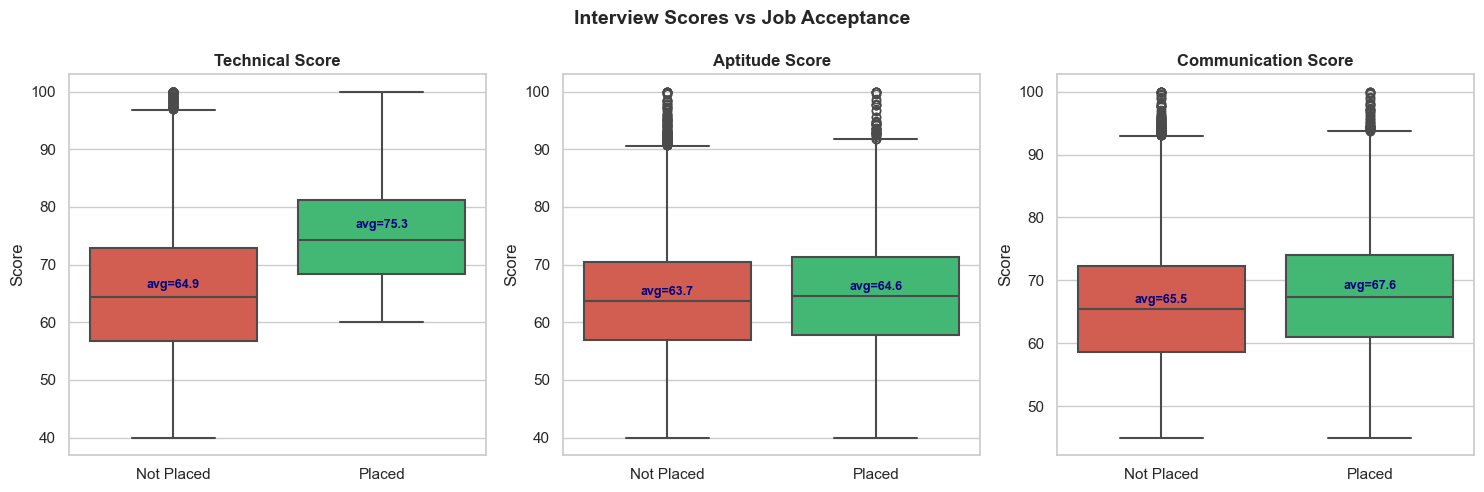

In [6]:
# ── CHART 2: Do higher scores = better placement? ──────────


fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns of charts

score_cols = ['technical_score', 'aptitude_score', 'communication_score']
titles     = ['Technical Score', 'Aptitude Score', 'Communication Score']

for ax, col, title in zip(axes, score_cols, titles):
    # boxplot: shows distribution of score split by placement status
    sns.boxplot(
        data=df,                          # our dataset
        x='status',                       # x-axis: Placed / Not Placed
        y=col,                            # y-axis: the score values
        hue='status',                     # color by status
        palette=PALETTE,                  # our red/green colors
        order=['Not Placed', 'Placed'],   # force this order left→right
        ax=ax,                            # which subplot to draw on
        linewidth=1.5,
        legend=False
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')

    # Add mean value label inside each box
    means = df.groupby('status')[col].mean()
    for i, status in enumerate(['Not Placed', 'Placed']):
        ax.text(i, means[status] + 1,
                f'avg={means[status]:.1f}',
                ha='center', fontsize=9,
                color='navy', fontweight='bold')

fig.suptitle('Interview Scores vs Job Acceptance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

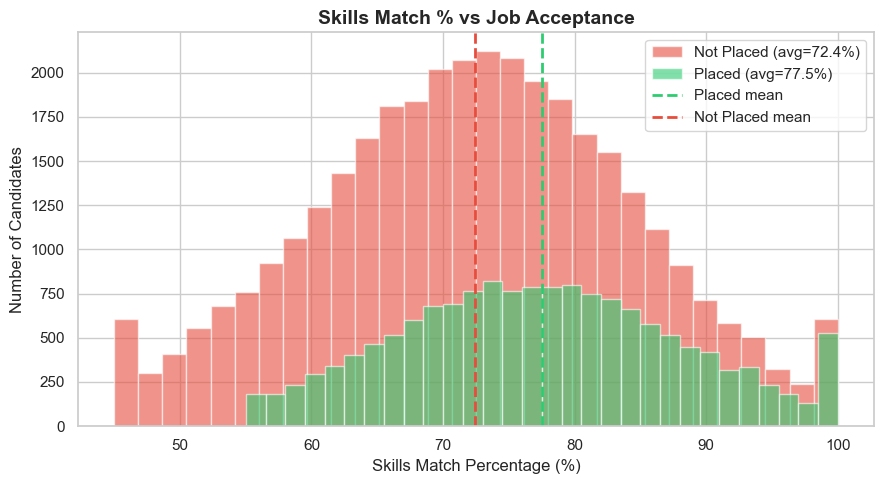

In [7]:
# ── CHART 3: Does skills match % affect placement? ─────────

fig, ax = plt.subplots(figsize=(9, 5))

# Draw one histogram for each status group
for status, color in zip(['Not Placed', 'Placed'], PALETTE):
    subset = df[df['status'] == status]['skills_match_percentage']
    ax.hist(
        subset,
        bins=30,         # divide data into 30 equal buckets
        alpha=0.6,       # 60% opacity so both histograms show through
        color=color,
        label=f'{status} (avg={subset.mean():.1f}%)',
        edgecolor='white'
    )

# Add vertical dashed lines at the MEAN of each group
ax.axvline(
    df[df['status'] == 'Placed']['skills_match_percentage'].mean(),
    color=PLACED_COLOR, linestyle='--', linewidth=2,
    label='Placed mean'
)
ax.axvline(
    df[df['status'] == 'Not Placed']['skills_match_percentage'].mean(),
    color=NOT_PLACED_COLOR, linestyle='--', linewidth=2,
    label='Not Placed mean'
)

ax.set_title('Skills Match % vs Job Acceptance', fontsize=14, fontweight='bold')
ax.set_xlabel('Skills Match Percentage (%)')
ax.set_ylabel('Number of Candidates')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\smada\AppData\Local\Temp\ipykernel_14140\4255861422.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tier_acc = df.groupby('company_tier').apply(


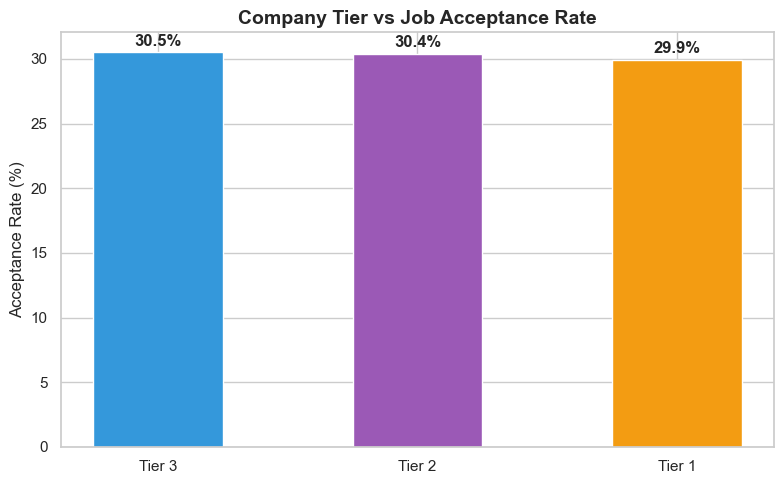

In [8]:
# ── CHART 4: Which company tier has best acceptance rate? ──



tier_acc = df.groupby('company_tier').apply(
    lambda x: (x['status'] == 'Placed').mean() * 100
    # lambda = a mini function: for each tier group x,
    #          count how many are 'Placed' and convert to %
).reset_index()
tier_acc.columns = ['company_tier', 'acceptance_rate']
tier_acc = tier_acc.sort_values('acceptance_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    tier_acc['company_tier'],
    tier_acc['acceptance_rate'],
    color=['#3498db', '#9b59b6', '#f39c12'],
    edgecolor='white', width=0.5
)

# Add % labels on top of bars
for bar, val in zip(bars, tier_acc['acceptance_rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontsize=12, fontweight='bold')

ax.set_title('Company Tier vs Job Acceptance Rate',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

C:\Users\smada\AppData\Local\Temp\ipykernel_14140\1322951199.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exp_acc = df.groupby('years_of_experience').apply(


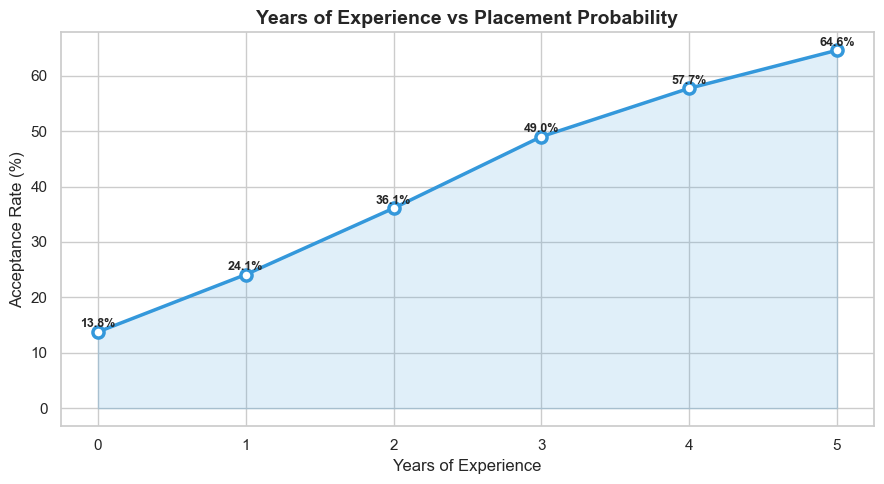

In [9]:
# ── CHART 5: Does more experience = higher placement? ──────

exp_acc = df.groupby('years_of_experience').apply(
    lambda x: (x['status'] == 'Placed').mean() * 100
).reset_index()
exp_acc.columns = ['years_of_experience', 'acceptance_rate']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    exp_acc['years_of_experience'],
    exp_acc['acceptance_rate'],
    marker='o',              # circle dot at each data point
    color='#3498db',
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white', # hollow circle
    markeredgewidth=2.5
)

# Shade the area under the line
ax.fill_between(exp_acc['years_of_experience'],
                exp_acc['acceptance_rate'],
                alpha=0.15, color='#3498db')

# Label each point with its exact %
for _, row in exp_acc.iterrows():
    ax.text(row['years_of_experience'],
            row['acceptance_rate'] + 0.8,
            f"{row['acceptance_rate']:.1f}%",
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Years of Experience vs Placement Probability',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

C:\Users\smada\AppData\Local\Temp\ipykernel_14140\1271339824.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comp_acc = df.groupby('competition_level').apply(


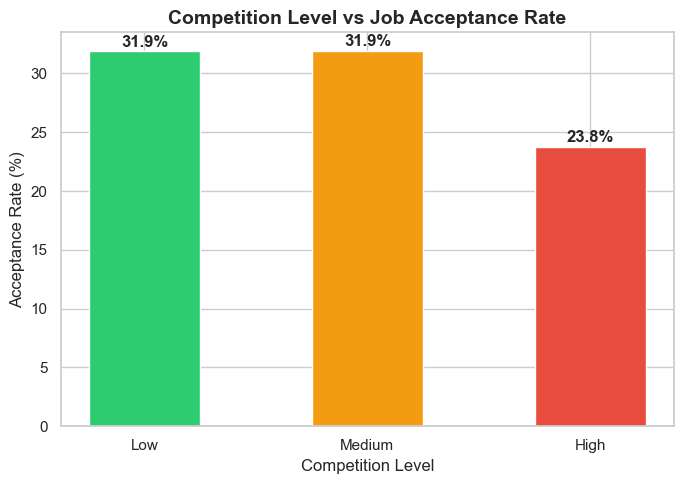

In [10]:
# ── CHART 6: Does competition level affect acceptance? ─────

comp_order = ['Low', 'Medium', 'High']    # force this specific order
comp_acc = df.groupby('competition_level').apply(
    lambda x: (x['status'] == 'Placed').mean() * 100
).reindex(comp_order).reset_index()
comp_acc.columns = ['competition_level', 'acceptance_rate']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    comp_acc['competition_level'],
    comp_acc['acceptance_rate'],
    color=['#2ecc71', '#f39c12', '#e74c3c'],  # green→orange→red
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, comp_acc['acceptance_rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center',
            fontsize=12, fontweight='bold')

ax.set_title('Competition Level vs Job Acceptance Rate',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_xlabel('Competition Level')
plt.tight_layout()
plt.show()

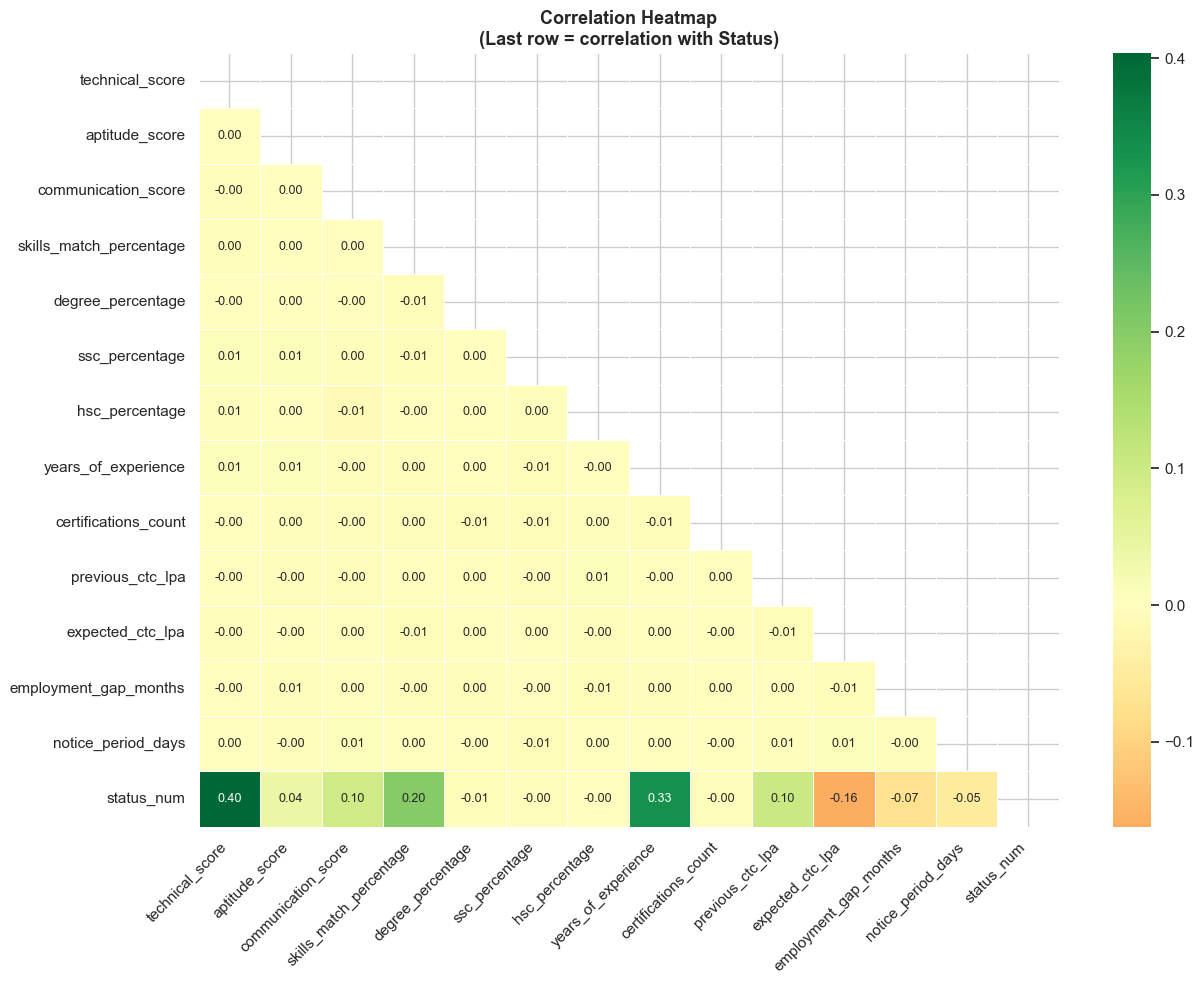

In [11]:
# ── CHART 7: How do ALL numeric features relate to each other?

# Create a numeric version of status for correlation
df['status_num'] = df['status'].map({'Placed': 1, 'Not Placed': 0})

num_cols = [
    'technical_score', 'aptitude_score', 'communication_score',
    'skills_match_percentage', 'degree_percentage',
    'ssc_percentage', 'hsc_percentage', 'years_of_experience',
    'certifications_count', 'previous_ctc_lpa',
    'expected_ctc_lpa', 'employment_gap_months',
    'notice_period_days', 'status_num'   # ← target at the end
]

# .corr() calculates correlation between every pair of columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

# mask hides the upper triangle (it's a mirror of the lower)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,          # hide upper triangle
    annot=True,         # show numbers inside each cell
    fmt='.2f',          # format: 2 decimal places
    cmap='RdYlGn',      # Red=negative, Yellow=zero, Green=positive
    center=0,           # 0 correlation = yellow (neutral)
    linewidths=0.5,     # thin lines between cells
    linecolor='white',
    annot_kws={'size': 9},
    ax=ax
)

ax.set_title('Correlation Heatmap\n(Last row = correlation with Status)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
df

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status,status_num
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed,0
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,Tier 1,Matched,High,Required,0.0,No,0.0,Not Willing,Not Placed,0
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed,1
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,Willing,Not Placed,0
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29,Female,76.382971,82.705920,81.790211,Electronics,71.955587,74.280744,65.613587,61.997596,...,Tier 2,Not Matched,Medium,Required,0.0,No,6.0,Willing,Not Placed,0
49996,32,Female,80.029965,68.803782,69.178840,Mechanical,53.488972,51.796635,75.373337,77.767081,...,Tier 3,Not Matched,High,Required,30.0,No,0.0,Willing,Not Placed,0
49997,28,Male,61.801411,69.771590,79.777937,Mechanical,60.530457,40.000000,54.851899,54.749371,...,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed,0
49998,34,Male,71.811897,76.840708,86.809844,Others,67.611868,44.373600,69.899354,92.333175,...,Tier 1,Matched,Low,Not Required,60.0,No,0.0,Not Willing,Not Placed,0


In [13]:
df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status', 'status_num'],
      dtype='object')